# Atelier Préparation de Données Textuelles

## Contexte 
Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client. 
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles. 

## Objectifs pédagogiques 
À la fin de l'atelier, l'apprenant doit être capable de : 
1) explorer un corpus textuel ; 
2) identifier les problèmes de qualité des données ; 
3) nettoyer les textes ; 
4) tokeniser les textes ; 
5) normaliser les données textuelles ; 
6) transformer les textes en représentations numériques ; 
7) comparer plusieurs méthodes de vectorisation ; 
8) préparer un corpus exploitable par un modèle de ML/DL.

## Partie 1:  Exploration du corpus

### 1) Charger les données CSV

In [1]:
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### 2) Combien d'avis contient le dataset ? 

In [2]:
nb_avis = df.shape[0]
print(f"Nombre d'avis : {nb_avis}")

Nombre d'avis : 1200


### 3) Combien de colonnes possède-t-il ? 

In [3]:
nb_colonnes = df.shape[1]
print(f"Nombre de colonnes : {nb_colonnes}")

Nombre de colonnes : 8


### 4) Quel est le type de chaque colonne ?

In [4]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 5) Existe-t-il des valeurs manquantes ? 

In [5]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères. 

In [6]:
import re

exemples = {
    "normal": df[df["texte"].notna() & (df["texte"].str.len() > 10)].iloc[0]["texte"],
    "vide": df[df["texte"].isna() | (df["texte"].str.strip() == "")].iloc[0]["texte"],
    "url": df[df["texte"].str.contains(r"http", case=False, na=False)].iloc[0]["texte"],
    "mention": df[df["texte"].str.contains(r"@\w+", na=False)].iloc[0]["texte"],
    "hashtag": df[df["texte"].str.contains(r"#\w+", na=False)].iloc[0]["texte"],
    "emoji": df[df["texte"].str.contains(r"[\U0001F300-\U0001FAFF]", na=False, regex=True)].iloc[0]["texte"],
    "ponctuation": df[df["texte"].str.count(r"[!?.]{2,}") > 0].iloc[0]["texte"],
    "majuscules": df[df["texte"].str.isupper() == True].iloc[0]["texte"],
    "repetition": df[df["texte"].str.contains(r"(.)\1{2,}", na=False, regex=True)].iloc[0]["texte"],
}

for cas, texte in exemples.items():
    print(f"{cas} : {texte}")

normal : Très  bonne  expérience,  simple  et  efficace.
vide : nan
url : Produit parfait, rien à signaler. https://example.com/commande/17
mention : @client Livraison rapide et produit conforme à mes attentes.
hashtag : Très satisfait de mon achat 👍 #avis
emoji : Très satisfait de mon achat 👍 #avis
ponctuation : Produit excellent, je suis très satisfait. !!!
majuscules : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
repetition : Produit excellent, je suis très satisfait. !!!


/tmp/ipykernel_9430/2826085732.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "repetition": df[df["texte"].str.contains(r"(.)\1{2,}", na=False, regex=True)].iloc[0]["texte"],


Explication : chaque motif est cherché avec une regex ciblée (@\w+ mention, #\w+ hashtag, plage Unicode emoji, (.)\1{2,} = un caractère répété 3+ fois) puis on prend le premier exemple trouvé (.iloc[0]).

### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [7]:
df["longueur"] = df["texte"].fillna("").apply(len)

print(df["longueur"].describe())

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64


Explication : apply(len) calcule le nombre de caractères par texte. .describe() donne d'un coup min, max, moyenne, médiane (50%) et quartiles (25%, 75%).

### 8) Visualiser la distribution de la longueur des avis

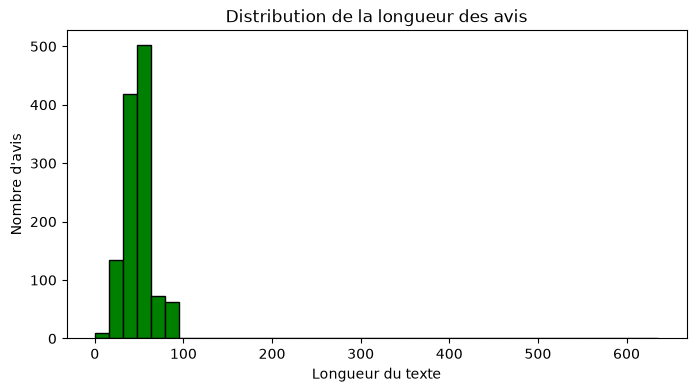

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["longueur"], bins=40, color="green", edgecolor="black")
plt.xlabel("Longueur du texte")
plt.ylabel("Nombre d'avis")
plt.title("Distribution de la longueur des avis")
plt.show()

### a) Existe-t-il des textes anormalement longs ?

Oui. L'histogramme est très concentré entre 0 et 100 caractères (l'essentiel des avis, avec un pic autour de 50-75), mais l'axe des abscisses s'étend jusqu'à 600, alors qu'aucune barre visible n'apparaît au-delà de 100. Cela indique la présence d'un ou plusieurs textes très longs (outliers), avec une longueur si rare comparée au reste qu'elle n'apparaît même pas comme une barre visible à cette échelle — c'est justement ce type d'étirement de l'axe qui trahit un outlier extrême, pas une distribution normale.

### b) Existe-t-il beaucoup de textes très courts ? 

Oui, dans une mesure modérée : on voit une petite barre proche de 0 (une dizaine d'avis) et une barre plus haute entre 0 et 25-30 (environ 130 avis). Ce n'est pas la majorité du dataset, mais ça représente une part non négligeable de textes courts, à surveiller pour la suite (un texte trop court porte peu d'information pour la classification de sentiment).

### 9) Détecter les textes vides 

In [13]:
textes_vides = df[df["texte"].isna() | (df["texte"].str.strip() == "")]
print(f"Nombre de textes vides : {len(textes_vides)}")
textes_vides.head()

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,0
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,0
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,0
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,0
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,0


Explication : un texte est « vide » soit parce qu'il est NaN (valeur manquante), soit parce que c'est une chaîne vide/espaces après strip()

### 10) Détecter les doublons sur le texte 

In [14]:
doublons = df[df.duplicated(subset="texte", keep=False)]
print(f"Nombre de lignes en doublon : {len(doublons)}")
doublons.sort_values("texte").head(10)

Nombre de lignes en doublon : 1036


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
312,AV0313,2026-04-18,mobile,Écouteurs AirSound,@client Excellent rapport qualité-prix.,positif,4,fr,39
419,AV0420,2026-04-11,sav,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1099,AV1100,2026-06-30,email,Tablette TabPlus,@client Excellent rapport qualité-prix.,positif,5,fr,39
45,AV0046,2026-08-26,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
466,AV0467,2026-07-04,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1059,AV1060,2026-01-24,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
146,AV0147,2026-08-11,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
593,AV0594,2026-06-11,mobile,SmartWatch Pro,@client Excellent rapport qualité-prix.,positif,4,fr,39
611,AV0612,2026-03-02,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
398,AV0399,2026-07-14,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39


Explication : duplicated(subset="texte", keep=False) marque toutes les occurrences d'un texte qui apparaît plusieurs fois (pas seulement la 2e copie), ce qui permet de bien voir les paires.

### 11) Les classes sont-elles équilibrées ? 

In [15]:
df["sentiment"].value_counts()
df["sentiment"].value_counts(normalize=True) * 100

sentiment
positif    64.666667
neutre     20.500000
negatif    14.833333
Name: proportion, dtype: float64

Explication : value_counts() compte chaque catégorie de sentiment ; normalize=True donne les proportions en %.

Les classes ne sont pas équilibrées :

**positif :** 64,7%. Largement majoritaire

**neutre :** 20,5%

**négatif :** 14,8%. Nettement minoritaire

Le déséquilibre est marqué : La classe positif représente presque 2/3 du dataset, soit plus de 4 fois la classe négatif. Un modèle entraîné tel quel aurait tendance à sur-prédire "positif" et à mal détecter les avis négatifs, pourtant souvent les plus utiles à repérer pour une entreprise (insatisfaction client).

### 12) Quelle est la classe majoritaire ?

In [16]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
print(f"Classe majoritaire : {classe_majoritaire}")

Classe majoritaire : positif


Explication : idxmax() renvoie l'index (ici le label de sentiment) correspondant à la valeur maximale du comptage.

### 13) Quelles métriques de classification à envisager d’utiliser ?

Vu le déséquilibre observé (positif 64,7% / neutre 20,5% / négatif 14,8%), l'accuracy seule est inadaptée : un modèle qui prédirait "positif" pour tout serait déjà correct 64,7% du temps sans avoir rien appris — un score trompeusement élevé.

**Métriques à privilégier :**

**F1-score macro**: Moyenne du F1 calculé indépendamment sur chaque classe, sans pondération par leur taille. C'est la métrique la plus importante ici : elle empêche la classe majoritaire (positif) de masquer les mauvaises performances sur négatif, la classe la plus rare et souvent la plus critique à détecter (insatisfaction client).

**Precision et Recall** par classe, en particulier sur négatif : le recall indique si le modèle rate des avis négatifs (faux négatifs coûteux pour l'entreprise), la precision indique s'il crie "négatif" à tort.

**Matrice de confusion**: pour visualiser concrètement où se trompe le modèle (ex. confond souvent neutre et négatif ?).

**Métriques à éviter comme seule mesure :**

**Accuracy globale**: masque les faiblesses sur les classes minoritaires (négatif à 14,8%).
**F1-score pondéré (weighted)**: à utiliser avec prudence : il repondère par la taille des classes, donc reste dominé par positif, ce qui limite son intérêt ici par rapport au macro.

**En résumé :** F1-score macro + matrice de confusion + recall sur la classe négative donnent une image fidèle des vraies performances, contrairement à l'accuracy qui serait artificiellement bonne à cause du déséquilibre 64,7/20,5/14,8.

### 14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; …

In [17]:
patterns = {
    "emojis": r"[\U0001F300-\U0001FAFF]",
    "urls": r"http\S+",
    "hashtags": r"#\w+",
    "mentions": r"@\w+",
    "chiffres": r"\d",
    "caracteres_speciaux": r"[^\w\s]",
    "ponctuation_repetee": r"([!?.]){2,}",
}

for nom, pattern in patterns.items():
    nb = df["texte"].fillna("").str.contains(pattern, regex=True).sum()
    print(f"{nom} : {nb} avis concernés")

emojis : 192 avis concernés
urls : 143 avis concernés
hashtags : 127 avis concernés
mentions : 128 avis concernés
chiffres : 142 avis concernés
caracteres_speciaux : 1190 avis concernés
ponctuation_repetee : 141 avis concernés


/tmp/ipykernel_9430/1619917755.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nb = df["texte"].fillna("").str.contains(pattern, regex=True).sum()


**Principe** :
- Chaque motif est défini par une expression régulière (regex) dans un dictionnaire `patterns`.
- Une boucle parcourt ce dictionnaire et applique `str.contains()` sur la colonne `texte` pour chaque motif.
- `.sum()` compte le nombre d'avis où le motif apparaît au moins une fois.

**Détail des regex utilisées** :

| Motif | Regex | Signification |
|---|---|---|
| emojis | `[\U0001F300-\U0001FAFF]` | plage Unicode couvrant la majorité des emojis |
| urls | `http\S+` | "http" suivi de caractères non-espacé |
| hashtags | `#\w+` | `#` suivi de caractères alphanumériques |
| mentions | `@\w+` | `@` suivi de caractères alphanumériques |
| chiffres | `\d` | présence d'au moins un chiffre |
| caractères spéciaux | `[^\w\s]` | tout caractère qui n'est ni alphanumérique ni un espace |
| ponctuation répétée | `([!?.]){2,}` | `!`, `?` ou `.` répété 2 fois ou plus |

`fillna("")` évite une erreur sur les valeurs manquantes avant l'application des regex.

### 15) Visualiser et commenter nombre d'avis par source

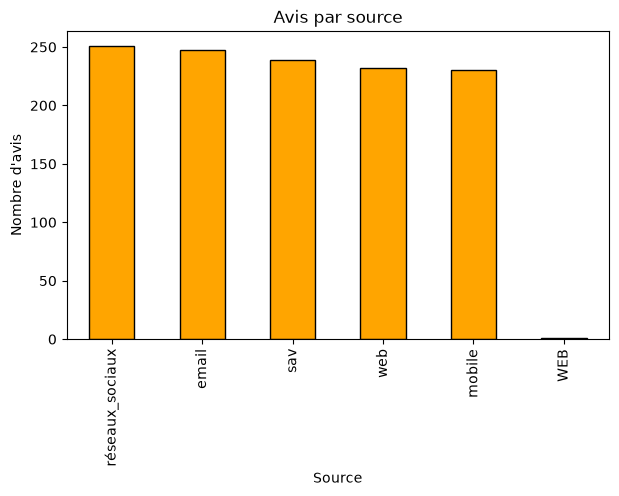

In [19]:
df["source"].value_counts().plot(kind="bar", figsize=(7,4), title="Avis par source", color="orange", edgecolor="black")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.show()

Les 5 sources principales sont relativement équilibrées, entre 230 et 250 avis chacune :

**réseaux_sociaux :** ~250 (source la plus représentée)
**email :** ~248
**sav :** ~238
**web :** ~232
**mobile :** ~230

Aucune source ne domine excessivement les autres contrairement au déséquilibre observé sur les classes de sentiment (Q11), la répartition par source est homogène, ce qui est plutôt rassurant pour éviter un biais lié à l'origine des avis.

Point important à corriger : une 6e barre apparaît, WEB (en majuscules), avec seulement 1-2 avis. C'est en réalité la même source que web, mais mal harmonisée (casse différente) — un problème classique de qualité des données mentionné dans le contexte de l'atelier ("majuscules/minuscules").